### chatbot with arxiv, wikipedia search

In [60]:
from langchain_community.tools  import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [61]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500) # type: ignore
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki) # type: ignore
print(wiki.name)



wikipedia


In [62]:
wiki.invoke("what is AI")

'Page: Artificial intelligence\nSummary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chan'

In [63]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY") # type: ignore
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY") # type: ignore



In [64]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

tavily.invoke("Provide current AI news")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': '#### Applications\n\n### Thailand becomes one of the first in Asia to get the Sora app\n\nEntertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n### Quantum AI represents a ‘transformative advancement’\n\nAI Hardware & Chips\n\nNovember 14, 2023\n\n#### Machine Learning\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### IDC: How EMEA CIOs can jumpstart AI rollouts [...] AI and

In [65]:
tools=[wiki,tavily]

In [66]:
from langchain_groq import ChatGroq

llm= ChatGroq(model="llama-3.1-8b-instant")

llm_with_tools=llm.bind_tools(tools)

In [67]:
from langchain_core.messages import AIMessage,HumanMessage


llm_with_tools.invoke([
    HumanMessage(content=f"What is the recent AI news")
])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4n1bxdwgf', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 404, 'total_tokens': 424, 'completion_time': 0.028619359, 'completion_tokens_details': None, 'prompt_time': 0.028786865, 'prompt_tokens_details': None, 'queue_time': 0.056162284, 'total_time': 0.057406224}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e11-49d7-7bc3-a8bf-9bbb9a0d0423-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': '4n1bxdwgf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 404, 'output_tokens': 20, 'total_tokens': 424})

In [68]:
llm_with_tools.invoke([
    HumanMessage(content=f"What is the recent AI news")
]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '2y0qg9e8s',
  'type': 'tool_call'}]

In [69]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

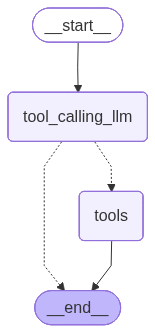

In [70]:
### ChatBot with LangGraph

from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)

graph= builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [71]:
messages=graph.invoke({"messages":HumanMessage(content="Top 10 AI recent news")}) # type: ignore

for message in messages["messages"]:
    message.pretty_print()



================================ Human Message =================================

Top 10 AI recent news
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (dzwcf5e83)
 Call ID: dzwcf5e83
  Args:
    query: Top 10 AI recent news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 AI Trends to Watch in 2026", "url": "https://www.usaii.org/ai-insights/top-10-ai-trends-to-watch-in-2026", "content": "5. Artificial General Intelligence (AGI)\n\nAGI refers to AI systems with human-like intelligence—able to learn, reason, and solve problems across different domains without task-specific training. Unlike narrow AI, AGI can adapt and generalize like a human mind.\n\nAs explored in USAII’s recent insights “Artificial General Intelligence (AGI): Challenges & Opportunities Ahead,” AGI also presents vast opportunities, from scientific discovery and 

In [72]:
messages=graph.invoke({"messages":HumanMessage(content="What is Machine Learning")}) # type: ignore

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (j2repyts4)
 Call ID: j2repyts4
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me
